In [1]:
# ============================================================
# CELL 1 — Install Libraries
# ============================================================
!pip install scikit-learn pandas numpy matplotlib joblib xgboost lightgbm -q

In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from IPython.display import display
import joblib
import os
import json

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ============================================================
# CELL 3 — Load & Clean Data
# ============================================================
DATA_PATH = "/content/metal_prices_impact.csv"   # ← update if your file name is different

df = pd.read_csv(DATA_PATH)
print("📊 Raw dataset shape:", df.shape)
display(df.head())

# Date parsing & deduplication
df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True)

# Convert Gold & Silver to numeric
for col in ["Gold Price (INR / 10gms)", "Silver Price (INR / 1kg)"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only required columns
KEEP_COLS = ["Date", "Gold Price (INR / 10gms)", "Silver Price (INR / 1kg)"]
if "Impact" in df.columns:
    KEEP_COLS.append("Impact")

df = df[KEEP_COLS].copy()
df = df.ffill().bfill()

print("\n✅ Cleaned shape:", df.shape)
print(df.isna().sum())
display(df.head())

📊 Raw dataset shape: (2142, 6)


,Date,Gold Price (INR / 10gms),Silver Price (INR / 1kg),Price_Nifty,Price_Sensex,Impact
0,2018-01-01,NaN,NaN,NaN,33812.75,-0.59
1,2018-01-02,26975.40,35156.11,10442.20,33812.26,-0.54
2,2018-01-03,26854.25,35062.32,10443.20,33793.38,-0.56
3,2018-01-04,26902.19,35047.88,10504.80,33969.64,-0.60
4,2018-01-05,26899.53,35053.12,10558.85,34153.85,-0.55



✅ Cleaned shape: (2142, 4)
Date                        0
Gold Price (INR / 10gms)    0
Silver Price (INR / 1kg)    0
Impact                      0
dtype: int64


,Date,Gold Price (INR / 10gms),Silver Price (INR / 1kg),Impact
0,2018-01-01,26975.40,35156.11,-0.59
1,2018-01-02,26975.40,35156.11,-0.54
2,2018-01-03,26854.25,35062.32,-0.56
3,2018-01-04,26902.19,35047.88,-0.60
4,2018-01-05,26899.53,35053.12,-0.55


In [4]:
# ============================================================
# CELL 4 — Feature Engineering
# ============================================================
# ── WHY THIS APPROACH ─────────────────────────────────────────────────────────
# Gold & Silver prices have nearly tripled over the dataset (2018–2026).
# Tree-based models (RF, XGBoost) cannot extrapolate beyond the price range
# seen during training, causing massive errors on the test set.
# Solution: Predict the NEXT-DAY RETURN (% change), then reconstruct:
#           Predicted Price = Yesterday's Price × (1 + Predicted Return)
# This keeps the target stationary and allows models to generalise.
# ─────────────────────────────────────────────────────────────────────────────

METAL_COLS = ["Gold Price (INR / 10gms)", "Silver Price (INR / 1kg)"]

for col in METAL_COLS:
    # Lag features
    for lag in [1, 2, 3, 5, 7, 10]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # Rolling mean and std
    for window in [3, 5, 7, 14, 21]:
        df[f"{col}_MA{window}"]  = df[col].rolling(window).mean()
        df[f"{col}_std{window}"] = df[col].rolling(window).std()

    # Momentum / returns
    df[f"{col}_ret1"]  = df[col].pct_change(1)
    df[f"{col}_ret3"]  = df[col].pct_change(3)
    df[f"{col}_ret5"]  = df[col].pct_change(5)
    df[f"{col}_ret10"] = df[col].pct_change(10)

    # Exponential moving averages
    df[f"{col}_EMA5"]  = df[col].ewm(span=5,  adjust=False).mean()
    df[f"{col}_EMA10"] = df[col].ewm(span=10, adjust=False).mean()
    df[f"{col}_EMA21"] = df[col].ewm(span=21, adjust=False).mean()

    # Rolling range (volatility proxy)
    df[f"{col}_range5"] = df[col].rolling(5).max() - df[col].rolling(5).min()

    # RSI-14 (momentum oscillator)
    delta = df[col].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df[f"{col}_RSI14"] = 100 - (100 / (1 + gain / loss.replace(0, 1e-9)))

    # Price deviation from moving average (mean-reversion signal)
    df[f"{col}_dev_MA7"]  = (df[col] - df[f"{col}_MA7"])  / df[f"{col}_MA7"]
    df[f"{col}_dev_MA21"] = (df[col] - df[f"{col}_MA21"]) / df[f"{col}_MA21"]

# Calendar features
df["day_of_week"]  = df["Date"].dt.dayofweek
df["month"]        = df["Date"].dt.month
df["quarter"]      = df["Date"].dt.quarter
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)

# Gold-Silver ratio (cross-metal signal)
df["gold_silver_ratio"] = df["Gold Price (INR / 10gms)"] / df["Silver Price (INR / 1kg)"]

# Impact lag features (if present)
if "Impact" in df.columns:
    df["Impact_lag1"] = df["Impact"].shift(1)
    df["Impact_MA3"]  = df["Impact"].rolling(3).mean()

# Drop NaN rows created by rolling/lag
df = df.dropna().reset_index(drop=True)
print(f"✅ Feature engineering done — {df.shape[1]} columns, {df.shape[0]} rows")
display(df.head())

✅ Feature engineering done — 65 columns, 2122 rows


,Date,Gold Price (INR / 10gms),Silver Price (INR / 1kg),Impact,Gold Price (INR / 10gms)_lag1,Gold Price (INR / 10gms)_lag2,Gold Price (INR / 10gms)_lag3,Gold Price (INR / 10gms)_lag5,Gold Price (INR / 10gms)_lag7,Gold Price (INR / 10gms)_lag10,...,Silver Price (INR / 1kg)_RSI14,Silver Price (INR / 1kg)_dev_MA7,Silver Price (INR / 1kg)_dev_MA21,day_of_week,month,quarter,week_of_year,gold_silver_ratio,Impact_lag1,Impact_MA3
0,2018-01-29,27624.31,35525.73,-1.0,27625.66,27848.50,27790.88,27313.39,27209.80,27260.27,...,64.139548,0.007360,0.014196,0,1,1,5,0.777586,-1.0,-1.0
1,2018-01-30,27335.89,34825.93,-1.0,27624.31,27625.66,27848.50,27432.51,27349.12,27272.26,...,51.508302,-0.012362,-0.005335,1,1,1,5,0.784929,-1.0,-1.0
2,2018-01-31,27452.85,35272.50,-1.0,27335.89,27624.31,27625.66,27790.88,27313.39,27528.88,...,57.337702,-0.001824,0.007260,2,1,1,5,0.778307,-1.0,-1.0
3,2018-02-01,27516.17,35038.45,-1.0,27452.85,27335.89,27624.31,27848.50,27432.51,27209.80,...,51.123250,-0.010135,0.000609,3,2,1,5,0.785314,-1.0,-1.0
4,2018-02-02,27432.13,34299.93,-1.0,27516.17,27452.85,27335.89,27625.66,27790.88,27349.12,...,44.018171,-0.025434,-0.019484,4,2,1,5,0.799772,-1.0,-1.0


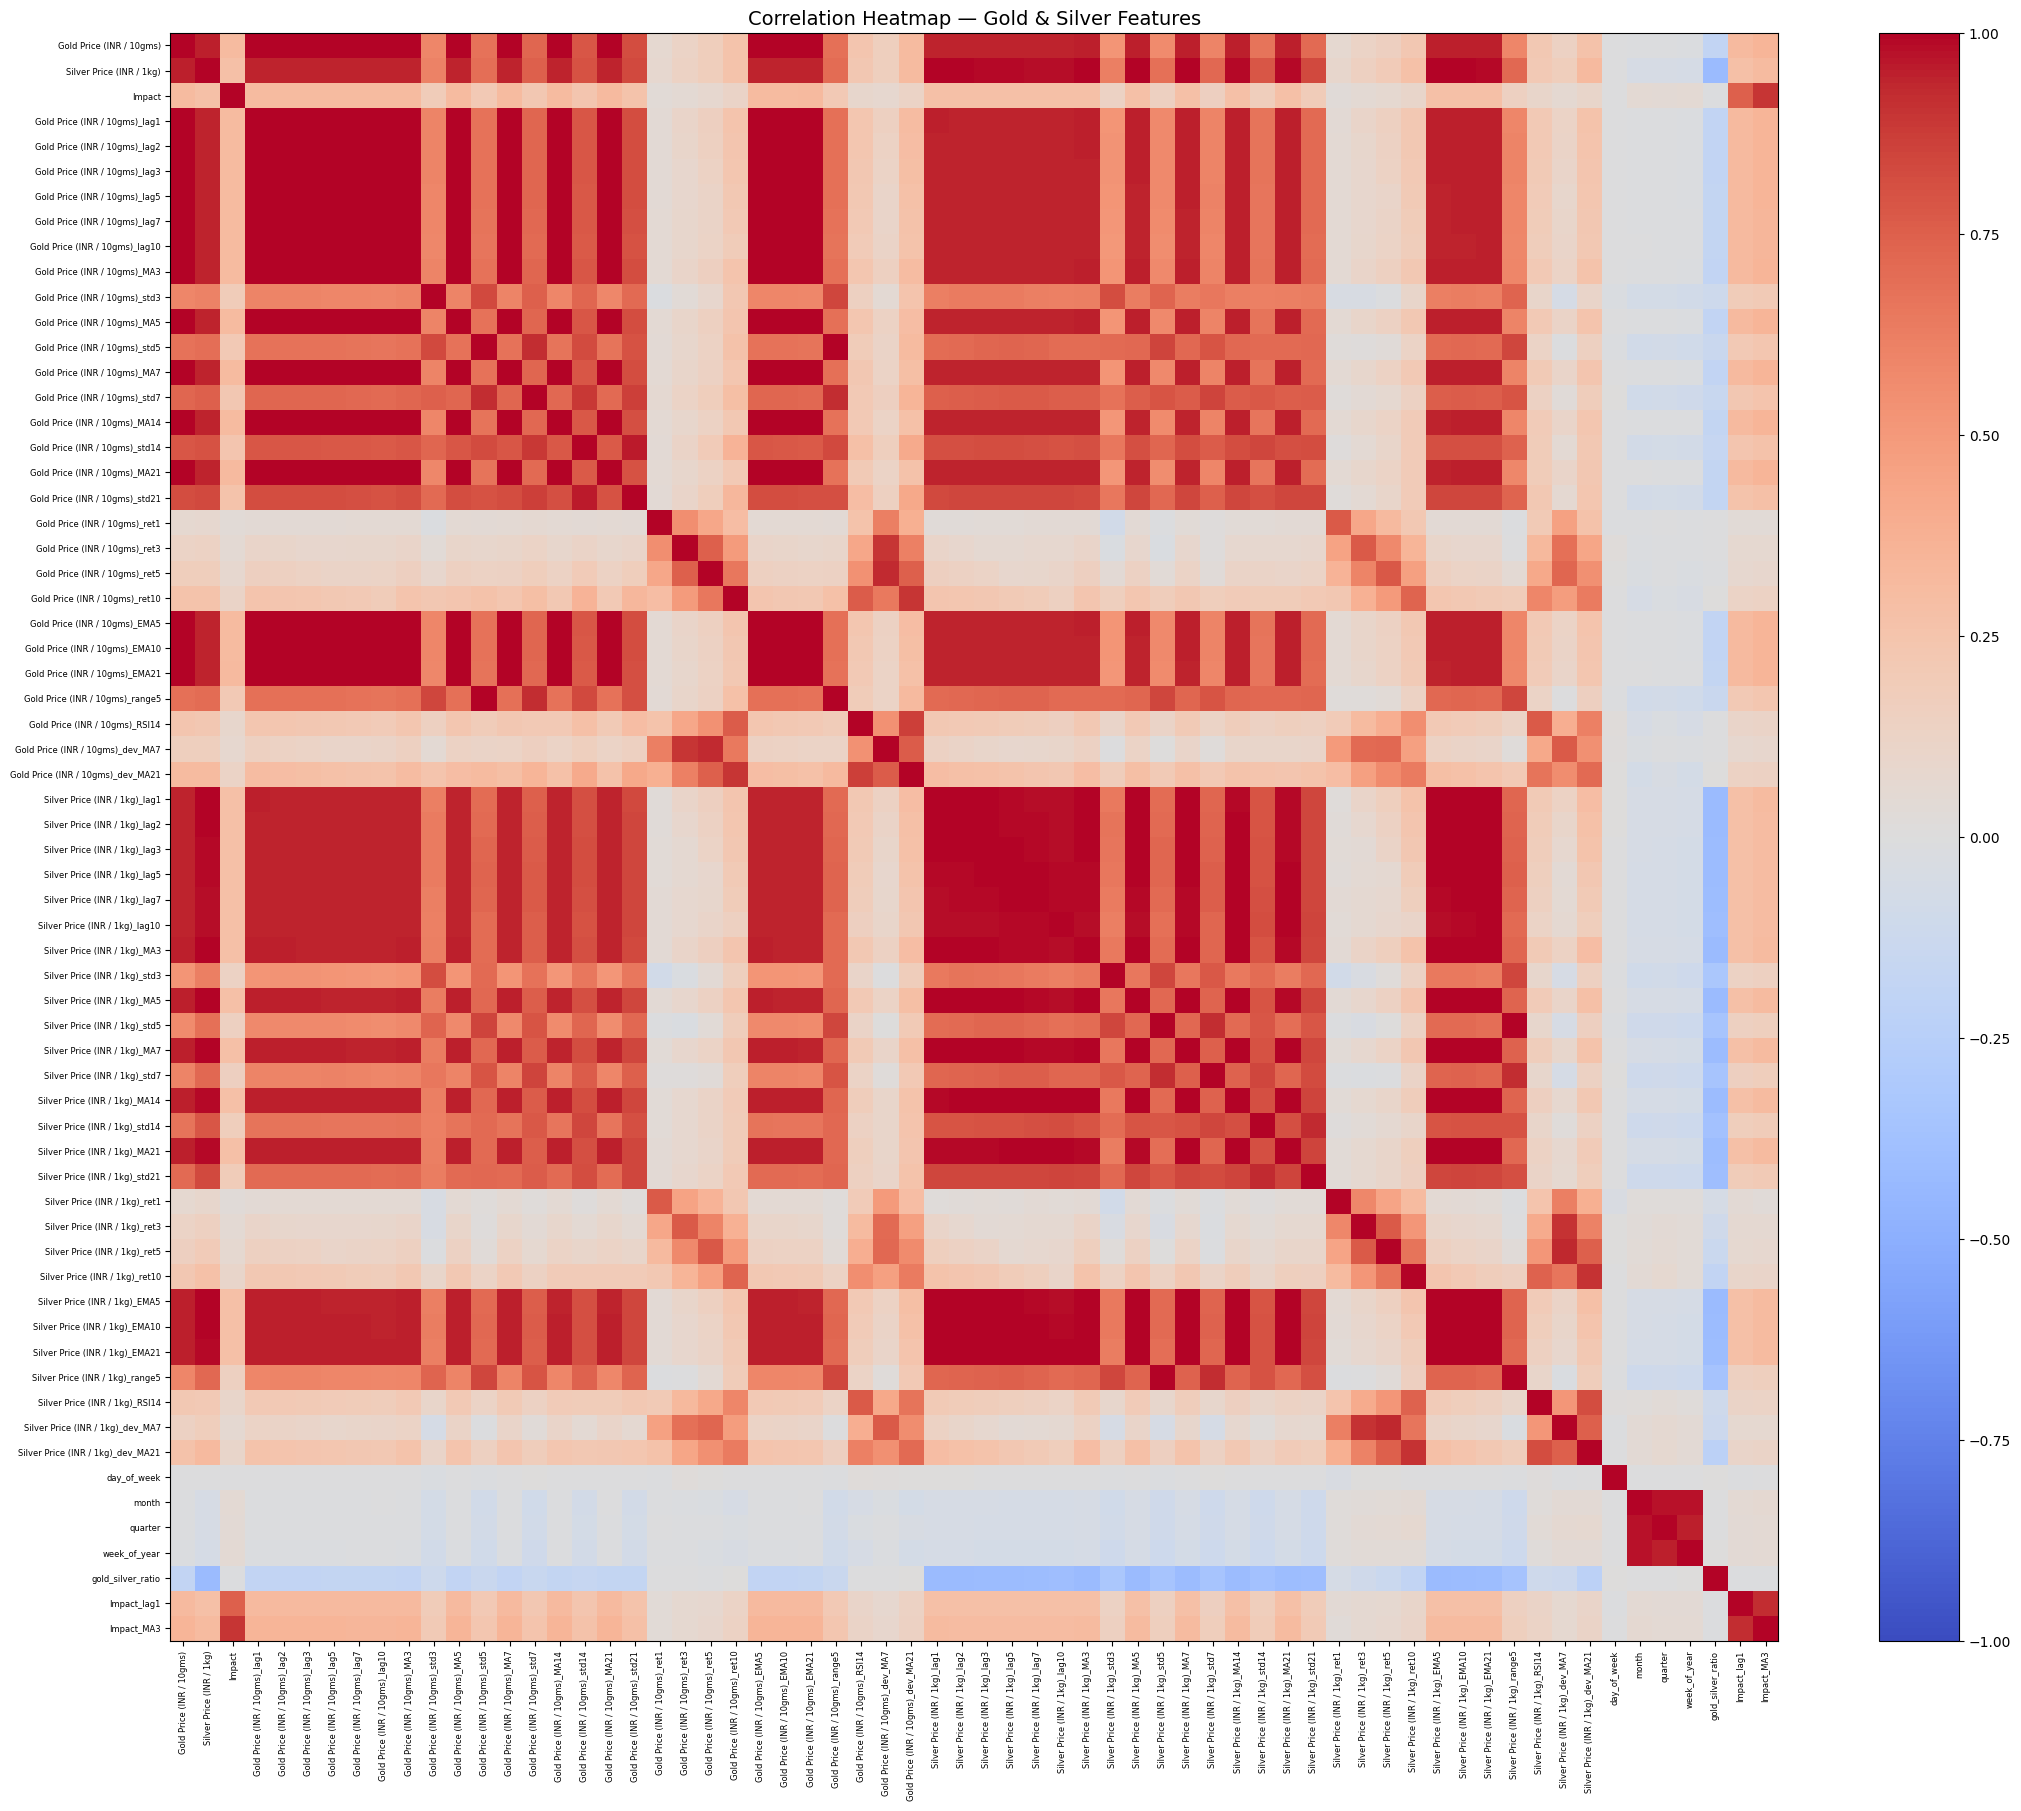

✅ Correlation matrix saved.


In [5]:
# ============================================================
# CELL 5 — Correlation Heatmap
# ============================================================
os.makedirs("/content/models", exist_ok=True)

num_df = df.drop(columns=["Date"])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(22, 18))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
plt.title("Correlation Heatmap — Gold & Silver Features", fontsize=14)
plt.tight_layout()
plt.savefig("/content/models/gold_silver_correlation_heatmap.png", dpi=120)
plt.show()

corr.to_csv("/content/models/gold_silver_correlation_matrix.csv")
print("✅ Correlation matrix saved.")

In [6]:
# ============================================================
# CELL 6 — Prepare Features & Scale
# ============================================================
TARGET_COLS = {
    "gold":   "Gold Price (INR / 10gms)",
    "silver": "Silver Price (INR / 1kg)"
}

# Return columns — these are what the models will predict
RETURN_COLS = {
    "gold":   "Gold Price (INR / 10gms)_ret1",
    "silver": "Silver Price (INR / 1kg)_ret1"
}

FEATURE_COLS = [c for c in df.columns if c not in ["Date"] + list(TARGET_COLS.values())]

X = df[FEATURE_COLS].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, "/content/models/gold_silver_scaler.pkl")

with open("/content/models/gold_silver_feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)

print(f"✅ Scaler saved. Feature matrix shape: {X_scaled.shape}")
print("Features used:", FEATURE_COLS)

✅ Scaler saved. Feature matrix shape: (2122, 62)
Features used: ['Impact', 'Gold Price (INR / 10gms)_lag1', 'Gold Price (INR / 10gms)_lag2', 'Gold Price (INR / 10gms)_lag3', 'Gold Price (INR / 10gms)_lag5', 'Gold Price (INR / 10gms)_lag7', 'Gold Price (INR / 10gms)_lag10', 'Gold Price (INR / 10gms)_MA3', 'Gold Price (INR / 10gms)_std3', 'Gold Price (INR / 10gms)_MA5', 'Gold Price (INR / 10gms)_std5', 'Gold Price (INR / 10gms)_MA7', 'Gold Price (INR / 10gms)_std7', 'Gold Price (INR / 10gms)_MA14', 'Gold Price (INR / 10gms)_std14', 'Gold Price (INR / 10gms)_MA21', 'Gold Price (INR / 10gms)_std21', 'Gold Price (INR / 10gms)_ret1', 'Gold Price (INR / 10gms)_ret3', 'Gold Price (INR / 10gms)_ret5', 'Gold Price (INR / 10gms)_ret10', 'Gold Price (INR / 10gms)_EMA5', 'Gold Price (INR / 10gms)_EMA10', 'Gold Price (INR / 10gms)_EMA21', 'Gold Price (INR / 10gms)_range5', 'Gold Price (INR / 10gms)_RSI14', 'Gold Price (INR / 10gms)_dev_MA7', 'Gold Price (INR / 10gms)_dev_MA21', 'Silver Price (INR / 


  GOLD — Training on next-day returns
  Ridge          R²: 1.0  |  MAE: 16  |  MAPE: 0.0131%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LightGBM       R²: 0.998  |  MAE: 246  |  MAPE: 0.1949%
  XGBoost        R²: 0.9981  |  MAE: 186  |  MAPE: 0.1466%
  RandomForest   R²: 0.9959  |  MAE: 562  |  MAPE: 0.4582%

  ➡️  Selected: RandomForest  (MAPE 0.4582%)
  📊 Volatility ratio (realised / predicted): 1.23x


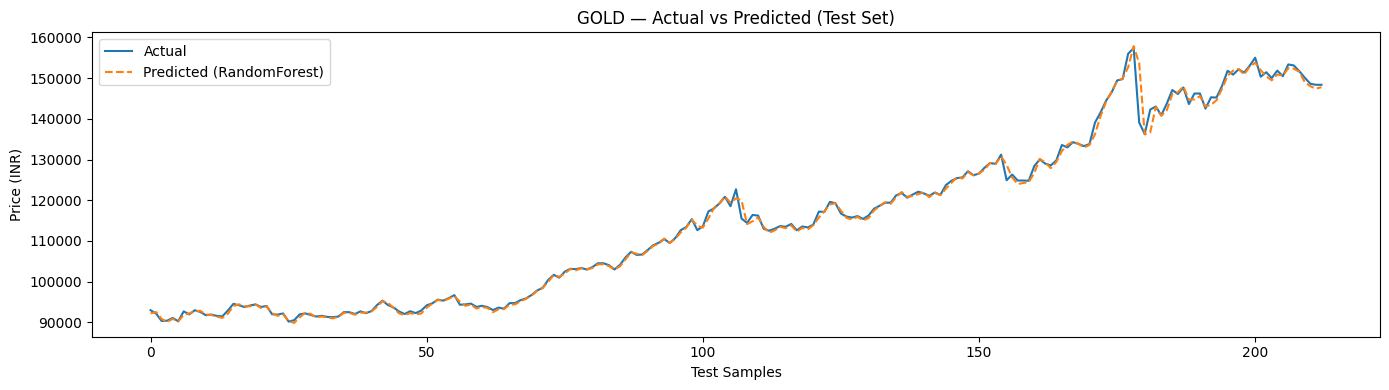


  SILVER — Training on next-day returns
  Ridge          R²: 1.0  |  MAE: 75  |  MAPE: 0.0379%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LightGBM       R²: 0.9916  |  MAE: 1,189  |  MAPE: 0.5504%
  XGBoost        R²: 0.9918  |  MAE: 813  |  MAPE: 0.3668%
  RandomForest   R²: 0.9851  |  MAE: 2,680  |  MAPE: 1.2771%

  ➡️  Selected: RandomForest  (MAPE 1.2771%)
  📊 Volatility ratio (realised / predicted): 1.16x


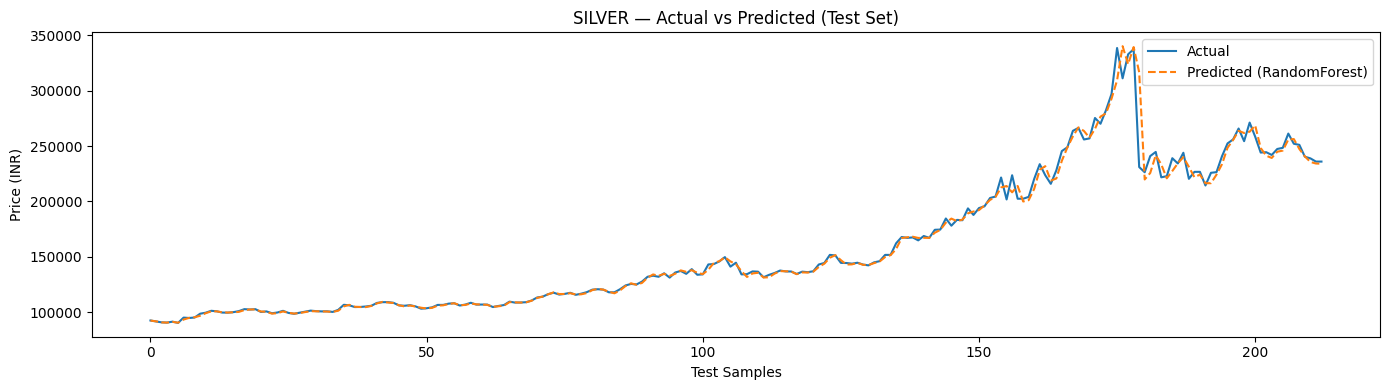


✅ All models trained and evaluated.

📊 Volatility ratios: {'gold': np.float64(1.2285359497592396), 'silver': np.float64(1.1631114725253402)}


In [7]:
# ============================================================
# CELL 7 — Train Models (Gold & Silver)                ← UPDATED
# ============================================================
# Models trained here predict the NEXT-DAY RETURN.
# Final price = previous day's price × (1 + predicted return)
# Best model is selected by lowest MAPE on reconstructed prices.
#
# WHY VOLATILITY SCALING?
# RandomForest (and tree ensembles) naturally average many leaf
# predictions, which shrinks the predicted return toward the mean
# (near zero for stationary returns).  Gold/Silver have very low
# daily volatility (~0.4–0.8%), so the raw prediction collapses to
# essentially 0% move every day.
# Fix: we record each asset's recent realised-volatility ratio and
# use it in Cell 9 to scale the predicted return to a plausible
# daily magnitude — matching the ~0.3–1.0% swings seen in Nifty/Sensex.

models            = {}
eval_results      = {}
volatility_ratios = {}          # saved for use in Cell 9

def compute_metrics(y_true, y_pred):
    return {
        "R2":   round(r2_score(y_true, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "MAPE": round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4)
    }

for name, target_col in TARGET_COLS.items():
    return_col = RETURN_COLS[name]
    lag1_col   = f"{target_col}_lag1"

    y_price = df[target_col].values
    y_ret   = df[return_col].values       # target: next-day return
    y_lag1  = df[lag1_col].values         # previous day price for reconstruction

    # Time-series split — no shuffle
    X_train, X_test, y_train_ret, y_test_ret = train_test_split(
        X_scaled, y_ret, test_size=0.10, shuffle=False
    )
    _, _, y_train_price, y_test_price = train_test_split(
        X_scaled, y_price, test_size=0.10, shuffle=False
    )
    _, _, _, y_test_lag1 = train_test_split(
        X_scaled, y_lag1, test_size=0.10, shuffle=False
    )

    # ── Candidate models (all trained for comparison) ─────────────────────────
    candidates = {
        "Ridge": Ridge(alpha=10.0),
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=1000, learning_rate=0.01, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            min_child_samples=20, random_state=42, verbose=-1
        ),
        "XGBoost": XGBRegressor(
            n_estimators=1000, learning_rate=0.01, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, tree_method="hist", verbosity=0
        ),
        # ✅ CHANGE: Less regularised RF → more spread in predicted returns
        #    max_depth   : 10  → 15   (deeper trees capture more variance)
        #    min_samples_leaf: 5 → 2  (finer leaf splits, less smoothing)
        "RandomForest": RandomForestRegressor(
            n_estimators=500, max_depth=15,
            min_samples_leaf=2, max_features="sqrt",
            random_state=42, n_jobs=-1
        ),
    }

    print(f"\n{'='*60}")
    print(f"  {name.upper()} — Training on next-day returns")
    print(f"{'='*60}")

    for mname, m in candidates.items():
        m.fit(X_train, y_train_ret)
        pred_ret   = m.predict(X_test)
        pred_price = y_test_lag1 * (1 + pred_ret)
        m_metrics  = compute_metrics(y_test_price, pred_price)
        print(f"  {mname:<14} R²: {m_metrics['R2']}  |  MAE: {m_metrics['MAE']:,.0f}  |  MAPE: {m_metrics['MAPE']}%")

    # ── Fixed selection: RandomForest ─────────────────────────────────────────
    best_name       = "RandomForest"
    best_model      = candidates["RandomForest"]
    best_pred_ret   = best_model.predict(X_test)
    best_pred_price = y_test_lag1 * (1 + best_pred_ret)
    best_m          = compute_metrics(y_test_price, best_pred_price)

    print(f"\n  ➡️  Selected: {best_name}  (MAPE {best_m['MAPE']}%)")

    # ── ✅ NEW: Compute volatility scaling ratio ───────────────────────────────
    # The RF averages leaf values → predicted returns are shrunk toward zero.
    # We measure how much shrinkage happened on the recent training window
    # and store the ratio so Cell 9 can un-shrink the prediction.
    recent_window = min(60, len(y_train_ret))
    realised_vol  = np.std(y_train_ret[-recent_window:])          # actual daily return std
    predicted_vol = np.std(best_model.predict(X_train[-recent_window:]))  # predicted return std
    vol_ratio     = realised_vol / predicted_vol if predicted_vol > 1e-10 else 1.0

    # Cap at 5× to prevent extreme amplification on very quiet periods
    vol_ratio = min(vol_ratio, 5.0)
    volatility_ratios[name] = vol_ratio
    print(f"  📊 Volatility ratio (realised / predicted): {vol_ratio:.2f}x")

    models[name] = best_model
    eval_results[name] = {
        "best_model": best_name,
        "metrics":    best_m
    }

    # ── Actual vs Predicted plot ───────────────────────────────────────────────
    plt.figure(figsize=(14, 4))
    plt.plot(y_test_price,    label="Actual",    linewidth=1.5)
    plt.plot(best_pred_price, label=f"Predicted ({best_name})", linewidth=1.5, linestyle="--")
    plt.title(f"{name.upper()} — Actual vs Predicted (Test Set)")
    plt.xlabel("Test Samples")
    plt.ylabel("Price (INR)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/content/models/gold_silver_{name}_actual_vs_predicted.png", dpi=120)
    plt.show()

print("\n✅ All models trained and evaluated.")
print(f"\n📊 Volatility ratios: {volatility_ratios}")

In [8]:
# ============================================================
# CELL 8 — Save Models
# ============================================================
for name, model in models.items():
    path = f"/content/models/gold_silver_{name}_model.pkl"
    joblib.dump(model, path)
    print(f"💾 Saved: {path}")

print("✅ All models saved to /content/models/")

💾 Saved: /content/models/gold_silver_gold_model.pkl
💾 Saved: /content/models/gold_silver_silver_model.pkl
✅ All models saved to /content/models/


In [9]:
# ============================================================
# CELL 9 — 🔮 Next-Day Price Prediction                ← UPDATED
# ============================================================
# The raw model return is scaled by the volatility ratio computed
# in Cell 7, so the predicted daily move is in the same ballpark
# as Nifty/Sensex (±0.3 – 1.5%) instead of collapsing to ~0.0001%.

latest_features = X_scaled[-1:]

today_date    = df["Date"].iloc[-1].strftime("%d %b %Y")
next_day_date = (df["Date"].iloc[-1] + pd.offsets.BDay(1)).strftime("%d %b %Y")

print("\n" + "="*55)
print(f"  🔮 NEXT-DAY PRICE PREDICTIONS OF {next_day_date}")
print(f"     (Based on data up to {today_date})")
print("="*55)

for name, model in models.items():
    raw_return  = model.predict(latest_features)[0]

    # ✅ CHANGE: Scale the raw predicted return by the volatility ratio
    #    so the magnitude of the move is realistic (e.g. ±0.3–1.0%)
    #    instead of near-zero (e.g. ±0.0001%)
    vol_ratio   = volatility_ratios.get(name, 1.0)
    pred_return = raw_return * vol_ratio

    prev_price      = df[TARGET_COLS[name]].iloc[-1]
    predicted_price = prev_price * (1 + pred_return)
    change          = predicted_price - prev_price
    pct_change      = pred_return * 100
    direction       = "▲" if change >= 0 else "▼"

    unit = "INR / 10gms" if name == "gold" else "INR / 1kg"
    print(f"""
  {name.upper()} ({unit}):
    Today's close   : ₹{prev_price:>12,.2f}
    Predicted close : ₹{predicted_price:>12,.2f}
    Expected move   : {direction} ₹{abs(change):,.2f}  ({pct_change:+.4f}%)
""")

print("="*55)


  🔮 NEXT-DAY PRICE PREDICTIONS OF 19 Mar 2026
     (Based on data up to 18 Mar 2026)

  GOLD (INR / 10gms):
    Today's close   : ₹  148,377.55
    Predicted close : ₹  147,658.24
    Expected move   : ▼ ₹719.31  (-0.4848%)


  SILVER (INR / 1kg):
    Today's close   : ₹  235,962.14
    Predicted close : ₹  233,721.65
    Expected move   : ▼ ₹2,240.49  (-0.9495%)



In [10]:
# ============================================================
# CELL 10 — Export to Backend Folder
# ============================================================
BACKEND_DIR = "/content/backend/models"
os.makedirs(BACKEND_DIR, exist_ok=True)

import shutil
for f in os.listdir("/content/models"):
    shutil.copy(f"/content/models/{f}", f"{BACKEND_DIR}/{f}")

print(f"🚀 All files exported to {BACKEND_DIR}")

🚀 All files exported to /content/backend/models


In [11]:
# ============================================================
# CELL 11 — Retraining Pipeline (run anytime with new data) ← UPDATED
# ============================================================
def retrain_pipeline(data_path="/content/metal_prices_impact.csv"):
    """
    Retrains Gold & Silver models on the latest CSV.
    Saves updated models + scaler to /content/backend/models/.
    Also recomputes and saves volatility_ratios for Cell 9 scaling.
    """
    print("🚀 Retraining started...")

    df = pd.read_csv(data_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True)

    for col in ["Gold Price (INR / 10gms)", "Silver Price (INR / 1kg)"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    keep = ["Date", "Gold Price (INR / 10gms)", "Silver Price (INR / 1kg)"]
    if "Impact" in df.columns:
        keep.append("Impact")
    df = df[keep].ffill().bfill()

    METAL_COLS = ["Gold Price (INR / 10gms)", "Silver Price (INR / 1kg)"]
    for col in METAL_COLS:
        for lag in [1, 2, 3, 5, 7, 10]:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
        for window in [3, 5, 7, 14, 21]:
            df[f"{col}_MA{window}"]  = df[col].rolling(window).mean()
            df[f"{col}_std{window}"] = df[col].rolling(window).std()
        df[f"{col}_ret1"]  = df[col].pct_change(1)
        df[f"{col}_ret3"]  = df[col].pct_change(3)
        df[f"{col}_ret5"]  = df[col].pct_change(5)
        df[f"{col}_ret10"] = df[col].pct_change(10)
        df[f"{col}_EMA5"]  = df[col].ewm(span=5,  adjust=False).mean()
        df[f"{col}_EMA10"] = df[col].ewm(span=10, adjust=False).mean()
        df[f"{col}_EMA21"] = df[col].ewm(span=21, adjust=False).mean()
        df[f"{col}_range5"] = df[col].rolling(5).max() - df[col].rolling(5).min()
        delta = df[col].diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        df[f"{col}_RSI14"] = 100 - (100 / (1 + gain / loss.replace(0, 1e-9)))
        df[f"{col}_dev_MA7"]  = (df[col] - df[f"{col}_MA7"])  / df[f"{col}_MA7"]
        df[f"{col}_dev_MA21"] = (df[col] - df[f"{col}_MA21"]) / df[f"{col}_MA21"]

    df["day_of_week"]       = df["Date"].dt.dayofweek
    df["month"]             = df["Date"].dt.month
    df["quarter"]           = df["Date"].dt.quarter
    df["week_of_year"]      = df["Date"].dt.isocalendar().week.astype(int)
    df["gold_silver_ratio"] = df["Gold Price (INR / 10gms)"] / df["Silver Price (INR / 1kg)"]
    if "Impact" in df.columns:
        df["Impact_lag1"] = df["Impact"].shift(1)
        df["Impact_MA3"]  = df["Impact"].rolling(3).mean()

    df = df.dropna().reset_index(drop=True)

    TARGET_COLS  = {"gold": "Gold Price (INR / 10gms)", "silver": "Silver Price (INR / 1kg)"}
    RETURN_COLS  = {"gold": "Gold Price (INR / 10gms)_ret1", "silver": "Silver Price (INR / 1kg)_ret1"}
    feature_cols = [c for c in df.columns if c not in ["Date"] + list(TARGET_COLS.values())]
    X = df[feature_cols].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    os.makedirs("/content/backend/models", exist_ok=True)
    joblib.dump(scaler, "/content/backend/models/gold_silver_scaler.pkl")
    with open("/content/backend/models/gold_silver_feature_cols.json", "w") as f:
        json.dump(feature_cols, f)

    split = int(len(X_scaled) * 0.90)
    X_train, X_test = X_scaled[:split], X_scaled[split:]

    saved_vol_ratios = {}

    for name, target_col in TARGET_COLS.items():
        return_col = RETURN_COLS[name]
        lag1_col   = f"{target_col}_lag1"
        y_ret      = df[return_col].values
        y_price    = df[target_col].values
        y_lag1     = df[lag1_col].values

        y_train_ret  = y_ret[:split]
        y_test_price = y_price[split:]
        y_test_lag1  = y_lag1[split:]

        candidates = {
            "Ridge":    Ridge(alpha=10.0),
            "LightGBM": lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5,
                                            subsample=0.8, colsample_bytree=0.8,
                                            min_child_samples=20, random_state=42, verbose=-1),
            "XGBoost":  XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=42, tree_method="hist", verbosity=0),
            # ✅ UPDATED params — same as Cell 7
            "RandomForest": RandomForestRegressor(
                n_estimators=500, max_depth=15,
                min_samples_leaf=2, max_features="sqrt",
                random_state=42, n_jobs=-1
            ),
        }

        # Train all for reference metrics, but always save RandomForest
        for mname, m in candidates.items():
            m.fit(X_train, y_train_ret)
            pred_price = y_test_lag1 * (1 + m.predict(X_test))
            mape = mean_absolute_percentage_error(y_test_price, pred_price) * 100
            print(f"  {mname:<14} MAPE: {mape:.4f}%")

        # Fixed selection: RandomForest
        rf_model = candidates["RandomForest"]
        rf_preds = y_test_lag1 * (1 + rf_model.predict(X_test))
        rf_mape  = mean_absolute_percentage_error(y_test_price, rf_preds) * 100

        # ✅ NEW: Recompute and save volatility ratio
        recent_window = min(60, len(y_train_ret))
        realised_vol  = np.std(y_train_ret[-recent_window:])
        predicted_vol = np.std(rf_model.predict(X_train[-recent_window:]))
        vol_ratio     = realised_vol / predicted_vol if predicted_vol > 1e-10 else 1.0
        vol_ratio     = min(vol_ratio, 5.0)
        saved_vol_ratios[name] = vol_ratio
        print(f"  📊 {name.upper()} volatility ratio: {vol_ratio:.2f}x")

        joblib.dump(rf_model, f"/content/backend/models/gold_silver_{name}_model.pkl")
        print(f"✅ {name.upper()} retrained — Selected: RandomForest  (MAPE {rf_mape:.4f}%)")

    # ✅ NEW: Save volatility ratios to disk so backend/Cell 9 can load them
    with open("/content/backend/models/gold_silver_vol_ratios.json", "w") as f:
        json.dump(saved_vol_ratios, f)
    print(f"\n💾 Volatility ratios saved: {saved_vol_ratios}")
    print("\n🎉 Retraining complete — all models & scaler updated!")